/var/folders/35/7zl99s1d6f5d4x0pchl5hyfm0000gn/T/ipykernel_446/728541736.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


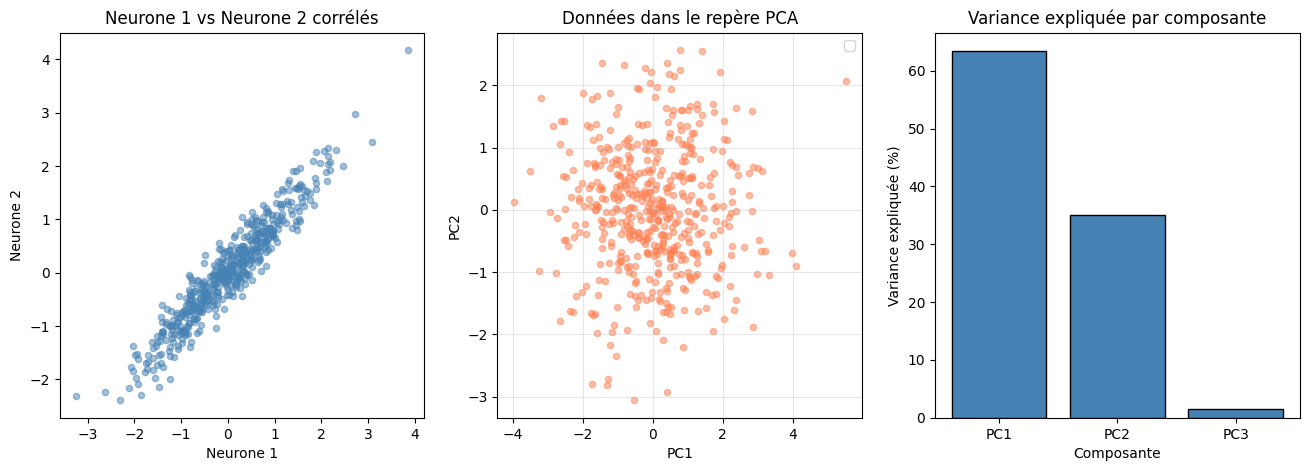

In [3]:
# Projet simulation de 3 neurones pendant 500 instants #

# Neurones - 2 premiers corrélés, troisime indépendant # 

import numpy as np 
import matplotlib.pyplot as plt 


np.random.seed(42)
n = 500

N1 = np.random.randn(n)
N2 = 0.95 * N1 + 0.3 * np.random.randn(n)
N3 = np.random.randn(n)

X = np.column_stack([N1, N2, N3])

# PCA - trois neurones # 
X_c = X - np.mean(X, axis=0)
Sigma = (1/n) * X_c.T @ X_c 
eigenvalues, P = np.linalg.eigh(Sigma)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
P = P[:, idx]
X_pca = X_c @ P
variance_expliquee = eigenvalues / eigenvalues.sum()


# Subplot 1 - scatter Neurone1 vs Neurone2 # 

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].scatter(N1, N2, alpha=0.5, s=20, color='steelblue')
ax[0].set_xlabel('Neurone 1')
ax[0].set_ylabel('Neurone 2')
ax[0].set_title('Neurone 1 vs Neurone 2 corrélés')


# Subplot 2 - scatter PC1 vs PC2 # 

ax[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=20, color='coral')
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')
ax[1].set_title('Données dans le repère PCA')
ax[1].grid(True, alpha=0.3)




# Subplot 3 - barplot variance expliquée # 

categories = ['PC1', 'PC2', 'PC3']
valeurs = variance_expliquee * 100 

ax[2].bar(categories, valeurs, color='steelblue', edgecolor='black')
ax[2].set_xlabel('Composante')
ax[2].set_ylabel('Variance expliquée (%)')
ax[2].set_title('Variance expliquée par composante')
ax[1].legend()
ax[1].grid(True, alpha=0.3)


